# Imports and load data

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pickle
import os
from pathlib import Path
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA

# defining a random seed for reproducibility
np.random.seed(42)

# loading the scaled data and encoded labels for training the MLP model
X_train_scaled = np.loadtxt('..\\data\\X_train_scaled.csv', delimiter=',')
y_train_encoded = np.loadtxt('..\\data\\y_train_encoded.csv', delimiter=',')

# loading the test data for later evaluation of the MLP model
X_test_scaled = np.loadtxt('..\\data\\X_test_scaled.csv', delimiter=',')   
y_test_encoded = np.loadtxt('..\\data\\y_test_encoded.csv', delimiter=',')

# converting the one-hot encoded labels back to their original class labels for later evaluation and visualization
y_test_true_labels = np.argmax(y_test_encoded, axis=1)
y_train_true_labels = np.argmax(y_train_encoded, axis=1)

# Creating class MLP only using numpy

In [2]:
class MLP_NP:
    def __init__(self, MLP_architecture, learning_rate, momentum, activation_function='sigmoid'):
       
        """
        MLP_architecture: [input_size (dataset features), hidden_layer1_size, hidden_layer2_size, ..., output_size (possible classes)]
        learning_rate: learning rate for weight updates
        momentum: momentum factor for weight updates
        activation_function: choice of activation function for hidden layers (default is 'sigmoid', can also be 'relu') and 'softmax' for output layer
        """
        self.MLP_architecture = MLP_architecture
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.activation_function = activation_function

        """
        weights: list of weight matrices for each layer (including input to first hidden layer and last hidden layer to output layer)
        biases: list of bias vectors for each layer (including first hidden layer and output layer)
        weight_speed: list of matrices to store the previous weight updates for momentum calculation
        bias_speed: list of vectors to store the previous bias updates for momentum calculation
        """
        self.weights = []
        self.biases = []
        self.weight_speed = []
        self.biases_speed = []
       
        # initialization of the weights and biases
        for i in range(len(MLP_architecture) - 1):
       
            # input and output size for the current layer
            input_size = MLP_architecture[i]
            output_size = MLP_architecture[i + 1]
            
            # initialize weights with small random values and biases with zeros
            weight_matrix = np.random.randn(input_size, output_size) * 0.1
            bias_vector = np.zeros((1, output_size))
           
            # store the initialized weights and biases in the respective lists
            self.weights.append(weight_matrix)
            self.biases.append(bias_vector)

            # Initialize speed matrices for momentum
            self.weight_speed.append(np.zeros_like(weight_matrix))
            self.biases_speed.append(np.zeros_like(bias_vector))
    
    """
    Activation functions: Sigmoid, ReLU, softmax, and their derivatives
    their porpouse is to introduce non-linearity into the model, allowing it to learn complex patterns in the data. The derivatives are used during backpropagation to compute gradients for weight updates.
    """
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    
    def sigmoid_derivative(self, x):
        s = self.sigmoid(x)
        return s * (1 - s)
    
    def relu(self, x):
        return np.maximum(0, x)
    
    def relu_derivative(self, x):
        return (x > 0).astype(float)
    
    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)
    
    """
    Forward pass: computes the output of the network for a given input by passing the data through each layer and applying the activation functions.
    """
    def forward_pass(self, X):

        """
        X: input data (shape: [num_samples, input_size])
        layer_inputs: list to store the inputs to each layer (including the original input X) for use in backpropagation
        layer_outputs: list to store the outputs of each layer for use in backpropagation
        """
        self.layer_inputs = []  
        self.layer_outputs = [] 
        
        input_data = X
        for i in range(len(self.MLP_architecture) - 1):

            # Compute the linear transformation (z) for the current layer and store it for backpropagation
            z = np.dot(input_data, self.weights[i]) + self.biases[i]
            self.layer_inputs.append(z)

            # Apply the appropriate activation function based on the layer type and the function specified in the constructor
            if i < len(self.MLP_architecture) - 2:  # Hidden layers
                if self.activation_function == 'sigmoid':
                    output_data = self.sigmoid(z)
                elif self.activation_function == 'relu':
                    output_data = self.relu(z)
                else:
                    raise ValueError("Unsupported activation function for hidden layers.")

            # aplying softmax activation function to the output layer regardless of the specified activation function for hidden layers, as softmax is typically used for multi-class classification problems        
            else:
                output_data = self.softmax(z)

            # Store the output of the current layer
            self.layer_outputs.append(output_data) 
            
            # The output of the current layer becomes the input for the next layer
            input_data = output_data  
        
        # Return the final output of the network
        return input_data  
    
    """
    Backward pass: computes the gradients of the loss with respect to the weights and biases by propagating the error backward through the network using the chain rule of calculus.
    """
    def backward_pass(self, X, y_true):

        # number of samples and predicted output from the forward pass
        m = X.shape[0] 
        y_pred = self.layer_outputs[-1] 

        # Compute the error at the output layer (using cross-entropy + softmax results in a simplified gradient)
        error = y_pred - y_true

        # Backpropagate the error through the layers in reverse order
        for i in reversed(range(len(self.MLP_architecture) - 1)):
            
            # seeing if is the first hidden layer (i=0) to determine the input for gradient calculation
            if i == 0:
                A_prev = X
            else:
                A_prev = self.layer_outputs[i - 1]

            # Calculate the gradients (dW and db) for the current layer
            dW = (1 / m) * np.dot(A_prev.T, error)
            db = (1 / m) * np.sum(error, axis=0, keepdims=True)

            # propagate the error to the previous layer (if not the first layer)
            if i > 0:

                # multiply the current error by the weights of the current layer (transposed) to get the error for the previous layer
                propagation_error = np.dot(error, self.weights[i].T)  
                
                # Apply the derivative of the activation function of the previous layer to the propagated error
                if self.activation_function == 'sigmoid':
                    activation_derivative = self.sigmoid_derivative(self.layer_inputs[i - 1])
                elif self.activation_function == 'relu':
                    activation_derivative = self.relu_derivative(self.layer_inputs[i - 1])
                else:
                    raise ValueError("Unsupported activation function for hidden layers.")
                
                # Update the error variable for the next iteration of the loop to continue backpropagation
                error = propagation_error * activation_derivative
            
            # calculate the momentum updates for weights and biases
            self.weight_speed[i] = self.momentum * self.weight_speed[i] - (self.learning_rate) * dW
            self.biases_speed[i] = self.momentum * self.biases_speed[i] - (self.learning_rate) * db

            # Update the weights and biases using the calculated momentum updates
            self.weights[i] += self.weight_speed[i]
            self.biases[i] += self.biases_speed[i]

# Preparing the training functions for the MLP

## A simple function for a single training run with a specific set of hyperparameters.

In [3]:
def single_train(X_train, y_train, epochs, architecture=None, learning_rate=None, momentum=None, activation_function=None):
    # Get user input for the architecture of the MLP, learning rate, momentum, and activation function
    
    if architecture is None:
        # Geting the number of hidden layers to construct the architecture of the MLP
        hidden_layer_sizes = []
        number_of_hidden_layers = int(input("Enter the number of hidden layers: "))
        for i in range(number_of_hidden_layers):

            # Get the size of each hidden layer from the user and store it in a list
            hidden_layer_size = int(input(f"Enter the size of hidden layer {i + 1}: "))
            hidden_layer_sizes.append(hidden_layer_size)

        # Creating the architecture of the MLP based on the input size, hidden layer sizes, and output size
        architecture = [X_train.shape[1]] + hidden_layer_sizes + [y_train.shape[1]]
    else:
        # Creating the architecture of the MLP based on the provided architecture and the input/output sizes
        architecture = [X_train.shape[1]] + architecture + [y_train.shape[1]]
    
    # Get user input for learning rate, momentum, and activation function for hidden layers
    if learning_rate is None:
        learning_rate = float(input("Enter the learning rate: "))

    if momentum is None:
        momentum = float(input("Enter the momentum factor: "))

    if activation_function is None:
        activation_function = input("Enter the activation function for hidden layers (sigmoid or relu): ")

    # Create an instance of the MLP_NP class with the specified architecture, learning rate, momentum, and activation function
    MLP_model = MLP_NP(architecture, learning_rate, momentum, activation_function)
    
    # Train the MLP for the specified number of epochs, performing forward and backward passes and printing the loss at each epoch
    for epoch in range(epochs):
        
        # Perform a forward pass to compute the predicted output
        y_pred = MLP_model.forward_pass(X_train)

        # Perform a backward pass to compute the gradients and update the weights and biases
        MLP_model.backward_pass(X_train, y_train)
 
        # loss for the current epoch (using cross-entropy loss)
        loss = np.mean(np.sum(-y_train * np.log(y_pred + 1e-8), axis=1))
        
        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch + 1}/{epochs}")
            print(f"Epoch Loss: {loss:.4f}")
    
    # After training, return the final loss for this configuration
    y_pred = MLP_model.forward_pass(X_train)
    loss = np.mean(np.sum(-y_train * np.log(y_pred + 1e-8), axis=1))
    print(f"Final Loss for this configuration: {loss:.4f}")
    return loss, MLP_model

## A function that performs a random search for hyperparameters and selects the best model.

In [8]:
def train_random_aux(X_train, y_train, epochs, architecture, learning_rate, momentum, activation_function, log_file=None):
    full_architecture = [X_train.shape[1]] + architecture + [y_train.shape[1]]
    # Create an instance of the MLP_NP class with the specified architecture, learning rate, momentum, and activation function
    MLP_model = MLP_NP(full_architecture, learning_rate, momentum, activation_function)
    
    # list to store the log of this training
    log = []

    # storing the initial configuration of this training in the log list and in the log file if provided
    config_line = f"Configuration: Architecture: {architecture}, Learning Rate: {learning_rate  }, Momentum: {momentum}, Activation Function: {activation_function}"
    log.append(config_line)
    if log_file:
        log_file.write(config_line + '\n')
    # Train the MLP for the specified number of epochs, performing forward and backward passes and printing the loss at each epoch
    for epoch in range(epochs):

        # Perform a forward pass to compute the predicted output
        y_pred = MLP_model.forward_pass(X_train)

        # Perform a backward pass to compute the gradients and update the weights and biases
        MLP_model.backward_pass(X_train, y_train)
 
        # print the loss for the current epoch (using cross-entropy loss)
        loss = np.mean(np.sum(-y_train * np.log(y_pred + 1e-8), axis=1))

        # if loss becomes invalid, stop this configuration immediately
        if np.isnan(loss) or np.isinf(loss):
            failure_line = "Training became unstable: loss is NaN or Inf. Skipping this configuration."
            log.append(failure_line)
            if log_file:
                log_file.write(failure_line + '\n')
            return loss, MLP_model, log
        
        # put every 10 epochs and the last epoch the log for this training
        if epoch % 10 == 0 or epoch == epochs - 1:
            epoch_line = f"Epoch {epoch + 1}/{epochs}"
            loss_line = f"Epoch Loss: {loss:.4f}"

            # store the log for this epoch in the log list
            log.extend([epoch_line, loss_line])
            
            if log_file:
                log_file.write(epoch_line + '\n')
                log_file.write(loss_line + '\n')
    # After training, return the final loss for this configuration
    y_pred = MLP_model.forward_pass(X_train)
    loss = np.mean(np.sum(-y_train * np.log(y_pred + 1e-8), axis=1))

    # final line for this training configuration
    log_final_line = f"Final Loss for this configuration: {loss:.4f}"
    log.append(log_final_line)
    if log_file:
        log_file.write(log_final_line + '\n' + '\n')

    return loss, MLP_model, log


def creating_random_architecture(num_random):    

    # creating the dictionary of lists for each hyperparameter to store the random values
    random_parameters = {   
        'hidden_layer': [],
        'learning_rate': [],
        'momentum': [],
        'activation_function': []
    }

    # creating predefined options for each hyperparameter to ensure a more meaningful search space for the random configurations

    # hidden layer architectures with varying number of layers and sizes to provide a diverse set of configurations for the MLP
    arquiteturas_opcoes = [
        [16],              
        [32, 32],          
        [16, 32],          
        [10, 20],          
        [16, 32, 64],      
        [64, 128, 64],
        [128, 64, 32],     
        [32, 64, 128],     
        [16, 16, 16],
        [8, 16, 32],
        [16, 32, 16]  
    ]
    
    # learning rates that span several orders of magnitude to allow for a wide exploration of the learning rate hyperparameter, which can significantly impact the training process and convergence of the MLP
    learning_rate_opcoes = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]
    
    # momentum values that are commonly used in training neural networks to help accelerate convergence and avoid local minima by adding a fraction of the previous weight update to the current update
    momentum_opcoes = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
    
    # activation functions that are widely used in neural networks to introduce non-linearity and allow the model to learn complex patterns in the data, with sigmoid being a traditional choice and ReLU being a popular choice for hidden layers due to its computational efficiency and ability to mitigate the vanishing gradient problem
    activation_opcoes = ['sigmoid', 'relu']
    
    # Generate random configurations for the specified number of times and store them in the respective lists
    for seed in range(1, num_random+1):
        random.seed(seed)

        hidden_layer_sizes = random.choice(arquiteturas_opcoes)
        random_parameters['hidden_layer'].append(hidden_layer_sizes)

        learning_rate = random.choice(learning_rate_opcoes)
        random_parameters['learning_rate'].append(learning_rate)

        momentum = random.choice(momentum_opcoes)
        random_parameters['momentum'].append(momentum)

        activation_function = random.choice(activation_opcoes)
        random_parameters['activation_function'].append(activation_function)
    
    return random_parameters



def random_train(X_train, y_train, epochs, num_random_configs=None, save_report=True):
    # Get the number of random configurations to try if not provided
    if num_random_configs is None:
        num_random_configs = int(input("Enter the number of random configurations to try: "))
    
    # Generate random configurations for the specified number of times
    random_parameters = creating_random_architecture(num_random_configs)

    # Train the MLP with each random configuration and store the results
    results = []

    # storing the log of all trainings in a single file (only if save_report is True)
    report_file = None if not save_report else open("..\\reports\\report_random_trainings.txt", "w")
    
    try:
        for i in range(num_random_configs):
            if i % 10 == 0 or i == num_random_configs - 1:
                print(f"Training with random configuration {i + 1}/{num_random_configs}")
            
            # Extract the random hyperparameters for the current configuration
            architecture = random_parameters['hidden_layer'][i]
            learning_rate = random_parameters['learning_rate'][i]
            momentum = random_parameters['momentum'][i]
            activation_function = random_parameters['activation_function'][i]

            # Train the MLP with the current random configuration and store the predicted output and loss
            loss, current_MLP_model, logs = train_random_aux(
                X_train, y_train, epochs, architecture, learning_rate, momentum, activation_function, log_file = report_file
                )

            # skip unstable configurations that produce NaN / Inf loss
            if np.isnan(loss) or np.isinf(loss):
                skip_line = (
                    f"Skipped unstable configuration {i + 1}/{num_random_configs}: "
                    f"architecture={architecture}, learning_rate={learning_rate}, "
                    f"momentum={momentum}, activation_function={activation_function}, loss={loss}"
                )
                print(skip_line)
                if report_file:
                    report_file.write(skip_line + '\n\n')
                continue
            
            # Store the results for the current configuration in a dictionary and append it to the results list
            config_result = {
                'architecture': architecture,
                'learning_rate': learning_rate,
                'momentum': momentum,
                'activation_function': activation_function,
                'loss': loss,
                'model': current_MLP_model,
                'logs' : logs
            }
            results.append(config_result)
    finally:
        # Ensure the report file is closed if it was opened
        if report_file:
            report_file.close()

    # if all configurations were unstable, stop with a clear message
    if not results:
        raise ValueError("No stable random configurations found; all produced NaN or Inf loss.")

    # finding the best configuration based on the lowest loss and returning the corresponding model
    best_config = min(results, key=lambda x: x['loss'])
    
    print(f"Log from the best configuration:")
    for log_entry in best_config['logs']:
        print(log_entry)
    print(f"Best configuration found:")
    print(f" Architecture: {best_config['architecture']}") 
    print(f" Learning Rate: {best_config['learning_rate']}") 
    print(f" Momentum: {best_config['momentum']}") 
    print(f" Activation Function: {best_config['activation_function']}") 
    print(f" Loss: {best_config['loss']:.4f}")
    
    if save_report:
        print(f"Report saved to ../reports/report_random_trainings.txt")
    
    return best_config['model'], best_config, results

# Training the MLP numpy version

## Training with a single set of hyperparameters

Epoch 1/150
Epoch Loss: 1.1264
Epoch 11/150
Epoch Loss: 1.0108
Epoch 21/150
Epoch Loss: 0.5489
Epoch 31/150
Epoch Loss: 0.3278
Epoch 41/150
Epoch Loss: 0.2350
Epoch 51/150
Epoch Loss: 0.1949
Epoch 61/150
Epoch Loss: 0.1666
Epoch 71/150
Epoch Loss: 0.1409
Epoch 81/150
Epoch Loss: 0.1162
Epoch 91/150
Epoch Loss: 0.1081
Epoch 101/150
Epoch Loss: 0.1089
Epoch 111/150
Epoch Loss: 0.1193
Epoch 121/150
Epoch Loss: 0.1293
Epoch 131/150
Epoch Loss: 0.1301
Epoch 141/150
Epoch Loss: 0.1299
Epoch 150/150
Epoch Loss: 0.1292
Final Loss for this configuration: 0.1289
Best model from single training saved to ../models/best_model_single.pkl
Test Loss for the model trained with user-defined hyperparameters: 0.2948
Test Accuracy for the model trained with user-defined hyperparameters: 1.0000
Test Precision for the model trained with user-defined hyperparameters: 1.0000
Test Recall for the model trained with user-defined hyperparameters: 1.0000
Test F1-Score for the model trained with user-defined hyperpa

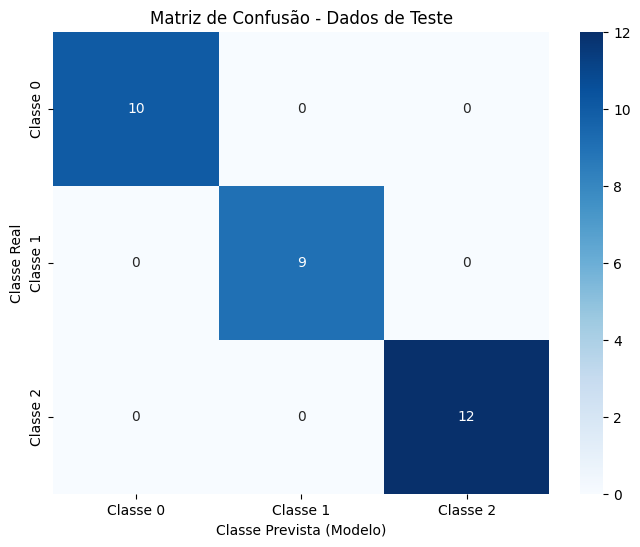

In [5]:
# Example of training the MLP with user-defined architecture and hyperparameters
final_loss_single, trained_model_single = single_train(X_train_scaled, y_train_encoded, epochs=150, architecture=[16], learning_rate=0.1, momentum=0.99, activation_function='sigmoid')

# Save the best model from single training
os.makedirs("../models", exist_ok=True)
with open("../models/best_model_single.pkl", "wb") as f:
    pickle.dump(trained_model_single, f)
print("Best model from single training saved to ../models/best_model_single.pkl")

# seeing the test loss for the model trained with user-defined hyperparameters
y_test_pred_single = trained_model_single.forward_pass(X_test_scaled)

# undooing the one-hot encoding from the predicted output to get the predicted class labels for the test set
y_test_pred_labels_single = np.argmax(y_test_pred_single, axis=1)

# calculating the metrics for the model trained with user-defined hyperparameters

# calculating the test loss using cross-entropy loss formula
test_loss_single = np.mean(np.sum(-y_test_encoded * np.log(y_test_pred_single + 1e-8), axis=1))
print(f"Test Loss for the model trained with user-defined hyperparameters: {test_loss_single:.4f}")

# calculating the test accuracy by comparing the true labels with the predicted labels for the test set
test_accuracy_single = accuracy_score(y_test_true_labels, y_test_pred_labels_single)
print(f"Test Accuracy for the model trained with user-defined hyperparameters: {test_accuracy_single:.4f}")

# calculating teh precision
test_precision_single = precision_score(y_test_true_labels, y_test_pred_labels_single, average='weighted')
print(f"Test Precision for the model trained with user-defined hyperparameters: {test_precision_single:.4f}")

# calculating the recall
test_recall_single = recall_score(y_test_true_labels, y_test_pred_labels_single, average='weighted')
print(f"Test Recall for the model trained with user-defined hyperparameters: {test_recall_single:.4f}")

# calculating the F1-score
test_f1_single = f1_score(y_test_true_labels, y_test_pred_labels_single, average='weighted')
print(f"Test F1-Score for the model trained with user-defined hyperparameters: {test_f1_single:.4f}")

# calculating the classification report (precision, recall, F1-score) for each class using the true labels and predicted labels for the test set
classification_rep_single = classification_report(y_test_true_labels, y_test_pred_labels_single)
print(f"Classification Report for the model trained with user-defined hyperparameters:\n{classification_rep_single}")

# plotting the confusion matrix for the model trained with user-defined hyperparameters to visualize the performance of the model in terms of true positives, true negatives, false positives, and false negatives for each class
cm = confusion_matrix(y_test_true_labels, y_test_pred_labels_single)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Classe 0', 'Classe 1', 'Classe 2'], 
            yticklabels=['Classe 0', 'Classe 1', 'Classe 2'])
plt.title('Matriz de Confusão - Dados de Teste')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista (Modelo)')
plt.show()

## Training with the random method

Training with random configuration 1/1000
Training with random configuration 11/1000
Training with random configuration 21/1000
Training with random configuration 31/1000
Training with random configuration 41/1000
Training with random configuration 51/1000
Training with random configuration 61/1000
Training with random configuration 71/1000
Training with random configuration 81/1000
Skipped unstable configuration 83/1000: architecture=[32, 64, 128], learning_rate=0.1, momentum=0.99, activation_function=relu, loss=nan


C:\Users\Guilherme\AppData\Local\Temp\ipykernel_4768\2484621655.py:83: RuntimeWarning: overflow encountered in dot
  z = np.dot(input_data, self.weights[i]) + self.biases[i]
C:\Users\Guilherme\AppData\Local\Temp\ipykernel_4768\2484621655.py:63: RuntimeWarning: invalid value encountered in subtract
  exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))


Training with random configuration 91/1000
Training with random configuration 101/1000
Training with random configuration 111/1000
Skipped unstable configuration 112/1000: architecture=[32, 64, 128], learning_rate=0.1, momentum=0.95, activation_function=relu, loss=nan


C:\Users\Guilherme\AppData\Local\Temp\ipykernel_4768\2484621655.py:137: RuntimeWarning: overflow encountered in dot
  propagation_error = np.dot(error, self.weights[i].T)
C:\Users\Guilherme\AppData\Local\Temp\ipykernel_4768\2484621655.py:148: RuntimeWarning: invalid value encountered in multiply
  error = propagation_error * activation_derivative


Training with random configuration 121/1000
Training with random configuration 131/1000
Training with random configuration 141/1000
Training with random configuration 151/1000
Training with random configuration 161/1000
Training with random configuration 171/1000
Training with random configuration 181/1000
Skipped unstable configuration 189/1000: architecture=[32, 64, 128], learning_rate=0.1, momentum=0.95, activation_function=relu, loss=nan
Training with random configuration 191/1000


C:\Users\Guilherme\AppData\Local\Temp\ipykernel_4768\2484621655.py:83: RuntimeWarning: invalid value encountered in dot
  z = np.dot(input_data, self.weights[i]) + self.biases[i]


Skipped unstable configuration 199/1000: architecture=[64, 128, 64], learning_rate=0.05, momentum=0.8, activation_function=relu, loss=nan
Training with random configuration 201/1000
Training with random configuration 211/1000
Training with random configuration 221/1000
Skipped unstable configuration 227/1000: architecture=[128, 64, 32], learning_rate=0.1, momentum=0.95, activation_function=relu, loss=nan
Training with random configuration 231/1000
Training with random configuration 241/1000
Training with random configuration 251/1000
Training with random configuration 261/1000
Skipped unstable configuration 262/1000: architecture=[64, 128, 64], learning_rate=0.1, momentum=0.9, activation_function=relu, loss=nan
Training with random configuration 271/1000
Skipped unstable configuration 271/1000: architecture=[32, 64, 128], learning_rate=0.05, momentum=0.7, activation_function=relu, loss=nan
Training with random configuration 281/1000
Training with random configuration 291/1000
Training 

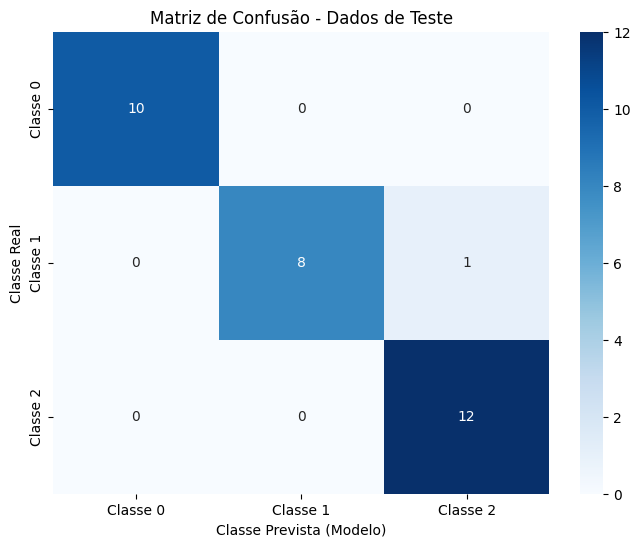

In [7]:
# Executing the random search method to train multiple configurations and find the best MLP architecture and hyperparameters
trained_model_random, parameters, all_results = random_train(X_train_scaled, y_train_encoded, epochs=150, num_random_configs=1000)

# Save the best model from random search
os.makedirs("../models", exist_ok=True)
with open("../models/best_model_random.pkl", "wb") as f:
    pickle.dump(trained_model_random, f)
print("Best model from random search saved to ../models/best_model_random.pkl")

# getting the predictions to calculate the test loss for the best model found by the random search method
y_test_pred_random = trained_model_random.forward_pass(X_test_scaled)

# undoing the one-hot encoding from the predicted output to get the predicted class labels for the test set
y_test_pred_labels_random = np.argmax(y_test_pred_random, axis=1)

# calculating the evaluation metrics for the best model found by the random search method

# calculating the test loss using cross-entropy loss formula
test_loss_random = np.mean(np.sum(-y_test_encoded * np.log(y_test_pred_random + 1e-8), axis=1))
print(f"Test Loss for the best model found by random search: {test_loss_random:.4f}")

# calculating the test accuracy
test_accuracy_random = accuracy_score(y_test_true_labels, y_test_pred_labels_random)
print(f"Test Accuracy for the best model found by random search: {test_accuracy_random:.4f}")

# calculating teh precision
test_precision_random = precision_score(y_test_true_labels, y_test_pred_labels_random, average='weighted')
print(f"Test Precision for the best model found by random search: {test_precision_random:.4f}")

# calculating the recall
test_recall_random = recall_score(y_test_true_labels, y_test_pred_labels_random, average='weighted')
print(f"Test Recall for the best model found by random search: {test_recall_random:.4f}")

# calculating the F1-score
test_f1_random = f1_score(y_test_true_labels, y_test_pred_labels_random, average='weighted')
print(f"Test F1-Score for the best model found by random search: {test_f1_random:.4f}")

# calculating the classification report (precision, recall, F1-score) for each class using the true labels and predicted labels for the test set
classification_rep_random = classification_report(y_test_true_labels, y_test_pred_labels_random)
print(f"Classification Report for the best model found by random search:\n{classification_rep_random}")

# plotting the confusion matrix for the best model found by the random search method to visualize the performance of the model in terms of true positives, true negatives, false positives, and false negatives for each class
cm = confusion_matrix(y_test_true_labels, y_test_pred_labels_random)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Classe 0', 'Classe 1', 'Classe 2'], 
            yticklabels=['Classe 0', 'Classe 1', 'Classe 2'])
plt.title('Matriz de Confusão - Dados de Teste')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista (Modelo)')
plt.show()

# Creating a discriminator only using 2 features of the iris dataset

## Preparing the new X and y using only the two most important features using PCA to create these features

In [10]:
# create a PCA object asking for only 2 components to reduce the dimensionality of the data to 2 dimensions for visualization purposes
pca = PCA(n_components=2)

# transform the original training data (already scaled) to 2 dimensions using PCA
X_train_2d = pca.fit_transform(X_train_scaled)

# seeing how much of the original variance is explained by these 2 principal components to understand how well the 2D representation captures the structure of the original data
print(f"Variance: {sum(pca.explained_variance_ratio_) * 100:.2f}%")

# training the MLP with the 2D representation of the data obtained through PCA
modelo_2d, configs_2d, results_2d = random_train(X_train_2d, y_train_encoded, epochs=150, num_random_configs=500, save_report=False)

Variance: 94.62%
Training with random configuration 1/500
Training with random configuration 11/500
Training with random configuration 21/500
Training with random configuration 31/500
Training with random configuration 41/500


C:\Users\Guilherme\AppData\Local\Temp\ipykernel_4768\2484621655.py:83: RuntimeWarning: overflow encountered in dot
  z = np.dot(input_data, self.weights[i]) + self.biases[i]
C:\Users\Guilherme\AppData\Local\Temp\ipykernel_4768\2484621655.py:137: RuntimeWarning: overflow encountered in dot
  propagation_error = np.dot(error, self.weights[i].T)
C:\Users\Guilherme\AppData\Local\Temp\ipykernel_4768\2484621655.py:148: RuntimeWarning: invalid value encountered in multiply
  error = propagation_error * activation_derivative


Skipped unstable configuration 50/500: architecture=[32, 64, 128], learning_rate=0.1, momentum=0.7, activation_function=relu, loss=nan
Training with random configuration 51/500
Training with random configuration 61/500
Training with random configuration 71/500
Training with random configuration 81/500
Skipped unstable configuration 83/500: architecture=[32, 64, 128], learning_rate=0.1, momentum=0.99, activation_function=relu, loss=nan


C:\Users\Guilherme\AppData\Local\Temp\ipykernel_4768\2484621655.py:83: RuntimeWarning: invalid value encountered in dot
  z = np.dot(input_data, self.weights[i]) + self.biases[i]
C:\Users\Guilherme\AppData\Local\Temp\ipykernel_4768\2484621655.py:63: RuntimeWarning: invalid value encountered in subtract
  exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))


Training with random configuration 91/500
Training with random configuration 101/500
Training with random configuration 111/500
Training with random configuration 121/500
Training with random configuration 131/500
Training with random configuration 141/500
Training with random configuration 151/500
Training with random configuration 161/500
Training with random configuration 171/500
Training with random configuration 181/500
Skipped unstable configuration 189/500: architecture=[32, 64, 128], learning_rate=0.1, momentum=0.95, activation_function=relu, loss=nan
Training with random configuration 191/500
Skipped unstable configuration 199/500: architecture=[64, 128, 64], learning_rate=0.05, momentum=0.8, activation_function=relu, loss=nan
Training with random configuration 201/500
Training with random configuration 211/500
Training with random configuration 221/500
Training with random configuration 231/500
Training with random configuration 241/500
Skipped unstable configuration 248/500:

## Function to plot the decision boundary using the two features

In [11]:
def plot_decision_boundary(X, y, model, title="Decision Boundary for MLP"):
    # limites the graph based on the minimum and maximum values of the features in the dataset, adding a small margin for better visualization
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    # creating grid points
    h = 0.05
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    # passing the grid through the model to get the predicted class for each point in the grid, which will be used to plot the decision boundary
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z_pred = model.forward_pass(grid_points)
    Z_pred_classes = np.argmax(Z_pred, axis=1) # Desfaz o one-hot encoding
    
    # matching the shape of Z with the grid for contour plotting
    Z = Z_pred_classes.reshape(xx.shape)
    
    # plot the decision boundary using a filled contour plot and overlay the original data points colored by their true class labels to visualize how well the model has learned to separate the classes in the 2D space
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.6, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='coolwarm')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

## Plotting the decision boundary on the train data

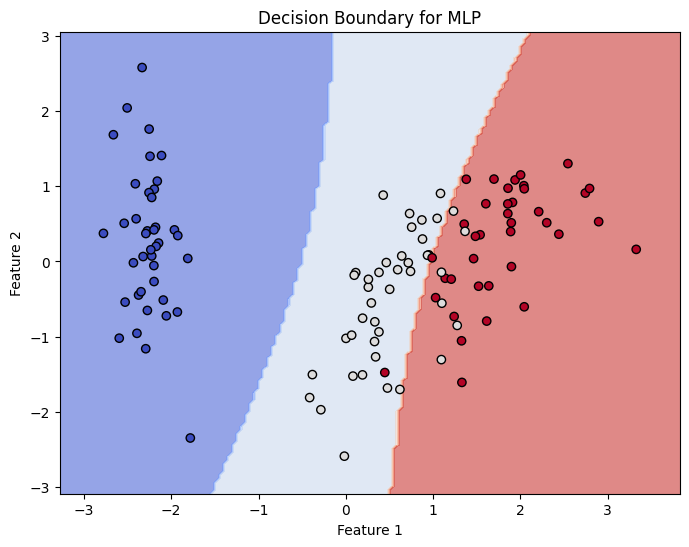

In [14]:
# plotting the decision boundary for training data in 2D using the best model found by the random search
plot_decision_boundary(X_train_2d, y_train_true_labels, modelo_2d)

## Plotting the decision boundary on the test data

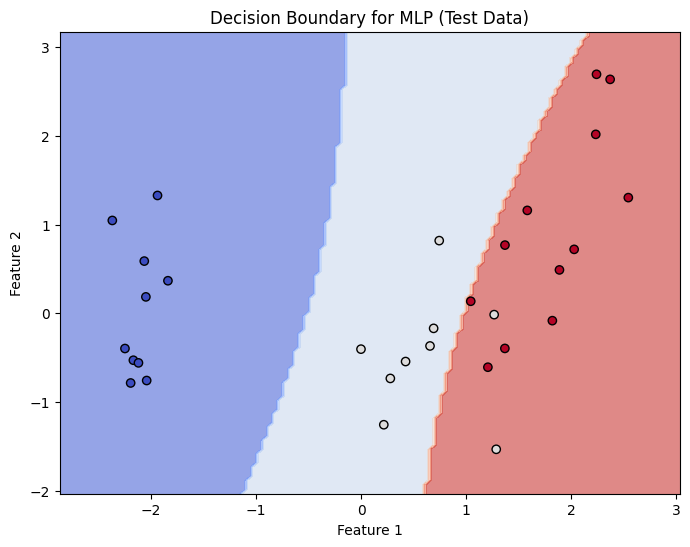

In [15]:
# Transform the test data to 2D using the same PCA that was fitted on training data
X_test_2d = pca.transform(X_test_scaled)

# Plot the decision boundary with test data points using the best model found by the random search
plot_decision_boundary(X_test_2d, y_test_true_labels, modelo_2d, title="Decision Boundary for MLP (Test Data)")